# Compare models for dense-traffic extension

Ce notebook évalue **tous les agents sur la config dense (`vehicles_density=2.0`)**, enregistre les métriques dans un **CSV cumulatif**, puis génère les tableaux et figures de comparaison.

Ordre évalué :
1. Random
2. DQN entraîné sur la core task
3. Stable-Baselines entraîné sur la core task
4. DQN dense_baseline
5. DQN dense_balanced
6. DQN dense_safety
7. Double DQN avec social attention

In [21]:
import os
from copy import deepcopy

import gymnasium as gym
import highway_env
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from stable_baselines3 import DQN

import sys
sys.path.insert(0, os.path.abspath("social_attention/rl-agents"))
from rl_agents.agents.common.factory import load_agent, load_environment

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [23]:
SHARED_CORE_ENV_ID = "highway-v0"

SHARED_CORE_CONFIG = {
    "observation": {
        "type": "Kinematics",
        "vehicles_count": 10,
        "features": ["presence", "x", "y", "vx", "vy"],
        "absolute": False,
        "normalize": True,
        "clip": True,
        "see_behind": True,
        "observe_intentions": False,
    },
    "action": {
        "type": "DiscreteMetaAction",
        "target_speeds": [20, 25, 30],
    },
    "lanes_count": 4,
    "vehicles_count": 45,
    "controlled_vehicles": 1,
    "initial_lane_id": None,
    "duration": 30,
    "ego_spacing": 2,
    "vehicles_density": 1.0,
    "collision_reward": -1.5,
    "right_lane_reward": 0.0,
    "high_speed_reward": 0.7,
    "lane_change_reward": -0.02,
    "reward_speed_range": [22, 30],
    "normalize_reward": True,
    "offroad_terminal": True,
}

DENSE_BASELINE_CONFIG = {
    **SHARED_CORE_CONFIG,
    "vehicles_density": 2.0,
}

DENSE_BALANCED_CONFIG = {
    **SHARED_CORE_CONFIG,
    "vehicles_density": 2.0,
    "collision_reward": -3.0,
    "high_speed_reward": 0.45,
    "lane_change_reward": -0.05,
}

DENSE_SAFETY_CONFIG = {
    **SHARED_CORE_CONFIG,
    "vehicles_density": 2.0,
    "collision_reward": -5.0,
    "high_speed_reward": 0.25,
    "lane_change_reward": -0.08,
}

EVAL_CONFIG = DENSE_BASELINE_CONFIG
EVAL_SEEDS = list(range(50))

ACTION_LABELS = {
    0: "LANE_LEFT",
    1: "IDLE",
    2: "LANE_RIGHT",
    3: "FASTER",
    4: "SLOWER",
}

def make_env(config=None, render_mode=None):
    env = gym.make(SHARED_CORE_ENV_ID, render_mode=render_mode)
    if config:
        env.unwrapped.config.update(config)
    return env

env = make_env(SHARED_CORE_CONFIG)
obs, _ = env.reset()
OBS_SIZE = obs.flatten().shape[0]
N_ACTIONS = env.action_space.n
env.close()

print("Observation shape :", obs.shape)
print("Action space      :", N_ACTIONS)
print("Flattened obs size:", OBS_SIZE)
print("Eval seeds        :", len(EVAL_SEEDS))

Observation shape : (10, 5)
Action space      : 5
Flattened obs size: 50
Eval seeds        : 50


## Paths

In [ ]:
CHECKPOINT_DIR = "extension_reward/checkpoints"

CORE_DQN_CHECKPOINT = os.path.join(CHECKPOINT_DIR, "dqn_core_baseline.pt")
DENSE_BASELINE_CHECKPOINT = os.path.join(CHECKPOINT_DIR, "dqn_dense_baseline.pt")
DENSE_BALANCED_CHECKPOINT = os.path.join(CHECKPOINT_DIR, "dqn_dense_balanced.pt")
DENSE_SAFETY_CHECKPOINT = os.path.join(CHECKPOINT_DIR, "dqn_dense_safety.pt")

STABLE_BASELINE_PATH = os.path.join(CHECKPOINT_DIR, "dqn_stable_baselines.zip")

SOCIAL_ATTENTION_PATH=os.path.join('social_attention', 'out', 'HighwayEnv', 'DQNAgent', 'saved_models', 'latest.tar')
# SOCIAL_ATTENTION_PATH="C:/Users/arfib/Documents/CentraleSupelec/cours 3A/RL Apprentissage par Renforcement/projet/Reinforcement_learning_highway/extension_task/social_attention/out/HighwayEnv/DQNAgent/run_20260403-095139_39712/checkpoint-final.tar"

for path in [
    CORE_DQN_CHECKPOINT,
    DENSE_BASELINE_CHECKPOINT,
    DENSE_BALANCED_CHECKPOINT,
    DENSE_SAFETY_CHECKPOINT,
    STABLE_BASELINE_PATH,
    SOCIAL_ATTENTION_PATH
]:
    print(path, "->", os.path.exists(path))

extension_reward/checkpoints\dqn_core_baseline.pt -> True
extension_reward/checkpoints\dqn_dense_baseline.pt -> True
extension_reward/checkpoints\dqn_dense_balanced.pt -> True
extension_reward/checkpoints\dqn_dense_safety.pt -> True
extension_reward/checkpoints\dqn_stable_baseline_longer_episodes.zip -> True
social_attention\out\HighwayEnv\DQNAgent\saved_models\latest.tar -> True


## Policies

In [25]:
class QNet(nn.Module):
    def __init__(self, obs_size, n_actions, hidden_size=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions),
        )

    def forward(self, x):
        return self.net(x)

def load_custom_qnet(checkpoint_path):
    model = QNet(OBS_SIZE, N_ACTIONS).to(device)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()
    return model

def make_custom_policy(checkpoint_path):
    model = load_custom_qnet(checkpoint_path)

    def get_action(obs):
        state_t = torch.FloatTensor(obs.flatten()).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = model(state_t)
        return int(q_values.argmax(dim=1).item())

    return get_action

def make_random_policy():
    def get_action(obs):
        return np.random.randint(N_ACTIONS)
    return get_action

def make_sb_policy(model_path):
    sb_model = DQN.load(model_path)

    def get_action(obs):
        action, _ = sb_model.predict(obs, deterministic=True)
        return int(action)

    return get_action

def make_social_attention_net_policy(model_path):
    
    base_path = os.path.abspath("social_attention/rl-agents/rl-agents/scripts")
    # agent_config = os.path.join(base_path, "configs/HighwayEnv/agents/DQNAgent/ego_attention.json")
    agent_config="C:/Users/arfib/Documents/CentraleSupelec/cours 3A/RL Apprentissage par Renforcement/projet/Reinforcement_learning_highway/extension_task/social_attention/rl-agents/scripts/configs/HighwayEnv/agents/DQNAgent/ego_attention.json"

    env = make_env(EVAL_CONFIG)
    agent = load_agent(agent_config, env)
    agent.load(filename=model_path)
    agent.eval()

    def get_action(obs):
        action=agent.act(obs, step_exploration_time=False)
        return int(action)

    return get_action

## Evaluation helpers

In [26]:
def eval_agent(get_action, config, eval_seeds):
    """
    Monte Carlo evaluation using fixed seeds.
    Returns:
        rewards, lengths, distances, collisions, action_lists
    """
    n_sim = len(eval_seeds)

    env = make_env(config)
    env_copy = deepcopy(env)

    episode_rewards = np.zeros(n_sim)
    episode_lengths = np.zeros(n_sim)
    episode_distances = np.zeros(n_sim)
    episode_collisions = np.zeros(n_sim, dtype=bool)
    episode_actions = []

    for i, seed in enumerate(eval_seeds):
        print(f"Simulating episode {i+1}/{n_sim} with seed {seed}")

        state, _ = env_copy.reset(seed=seed)
        reward_sum = 0.0
        length = 0
        distance = 0.0
        actions = []
        done = False

        while not done:
            action = get_action(state)
            actions.append(action)
            state, reward, terminated, truncated, _ = env_copy.step(action)

            reward_sum += reward
            length += 1

            dt = 1 / env_copy.unwrapped.config["simulation_frequency"]
            speed = env_copy.unwrapped.vehicle.speed
            distance += speed * dt

            done = terminated or truncated

        if terminated:
            episode_collisions[i] = True

        episode_rewards[i] = reward_sum
        episode_lengths[i] = length
        episode_distances[i] = distance
        episode_actions.append(actions)

    env_copy.close()
    env.close()
    return episode_rewards, episode_lengths, episode_distances, episode_collisions, episode_actions

def compute_metrics(eval_output):
    rewards, lengths, distances, collisions, actions = eval_output

    metrics = {
        "mean_reward": float(rewards.mean()),
        "std_reward": float(rewards.std()),
        "mean_episode_length": float(lengths.mean()),
        "std_episode_length": float(lengths.std()),
        "mean_distance": float(distances.mean()),
        "std_distance": float(distances.std()),
        "success_rate": float(100 * (~collisions).mean()),
        "collision_rate": float(100 * collisions.mean()),
    }

    all_actions = np.concatenate(actions) if len(actions) > 0 else np.array([], dtype=int)
    counts = np.bincount(all_actions, minlength=N_ACTIONS) if all_actions.size > 0 else np.zeros(N_ACTIONS, dtype=int)
    total_actions = counts.sum()

    for a in range(N_ACTIONS):
        metrics[f"action_count_{a}"] = int(counts[a])
        metrics[f"action_pct_{a}"] = float(100 * counts[a] / total_actions) if total_actions > 0 else 0.0

    return metrics

def print_eval_metrics(eval_output, label="Agent"):
    metrics = compute_metrics(eval_output)

    print(f"Evaluation Results for network {label}")
    print(f"Reward: mean = {metrics['mean_reward']:.3f}, std = {metrics['std_reward']:.3f}")
    print(f"Length: mean = {metrics['mean_episode_length']:.2f}, std = {metrics['std_episode_length']:.2f}")
    print(f"Distance: mean = {metrics['mean_distance']:.2f}, std = {metrics['std_distance']:.2f}")
    print(f"No collision: {metrics['success_rate']:.1f}%")
    print(f"Collision: {metrics['collision_rate']:.1f}%")

    print("Action distribution:")
    for a in range(N_ACTIONS):
        action_name = ACTION_LABELS.get(a, str(a))
        print(f"  {action_name}: {metrics[f'action_count_{a}']} ({metrics[f'action_pct_{a}']:.1f}%)")

    return metrics

def plot_action_distribution(eval_output, n_actions, action_labels=None, title="Action distribution"):
    _, _, _, _, episode_actions = eval_output

    all_actions = np.concatenate(episode_actions)
    counts = np.bincount(all_actions, minlength=n_actions)

    if action_labels is None:
        labels = [str(i) for i in range(n_actions)]
    else:
        labels = [action_labels.get(i, str(i)) for i in range(n_actions)]

    x = np.arange(n_actions)

    plt.figure(figsize=(6, 4))
    plt.bar(x, counts, alpha=0.8)
    plt.xticks(x, labels, rotation=15)
    plt.ylabel("Count")
    plt.title(title)
    plt.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

## CSV logging

In [27]:
RESULTS_DIR = "results"
RESULTS_CSV = os.path.join(RESULTS_DIR, "extension_results_dense_eval_all.csv")
os.makedirs(RESULTS_DIR, exist_ok=True)

RESULT_COLUMNS = [
    "model",
    "reward_profile",
    "train_density",
    "eval_density",
    "collision_reward",
    "high_speed_reward",
    "lane_change_reward",
    "mean_reward",
    "std_reward",
    "mean_episode_length",
    "std_episode_length",
    "mean_distance",
    "std_distance",
    "success_rate",
    "collision_rate",
    "action_count_0",
    "action_count_1",
    "action_count_2",
    "action_count_3",
    "action_count_4",
    "action_pct_0",
    "action_pct_1",
    "action_pct_2",
    "action_pct_3",
    "action_pct_4",
    "notes",
]

def load_results_table():
    if os.path.exists(RESULTS_CSV):
        df = pd.read_csv(RESULTS_CSV)
        for col in RESULT_COLUMNS:
            if col not in df.columns:
                df[col] = None
        df = df[RESULT_COLUMNS]
    else:
        df = pd.DataFrame(columns=RESULT_COLUMNS)
    return df

def build_result_row(model, reward_profile, train_density, eval_density, metrics, config=None, notes=None):
    row = {
        "model": model,
        "reward_profile": reward_profile,
        "train_density": train_density,
        "eval_density": eval_density,
        "mean_reward": metrics["mean_reward"],
        "std_reward": metrics["std_reward"],
        "mean_episode_length": metrics["mean_episode_length"],
        "std_episode_length": metrics["std_episode_length"],
        "mean_distance": metrics["mean_distance"],
        "std_distance": metrics["std_distance"],
        "success_rate": metrics["success_rate"],
        "collision_rate": metrics["collision_rate"],
        "notes": notes,
    }

    for a in range(N_ACTIONS):
        row[f"action_count_{a}"] = metrics[f"action_count_{a}"]
        row[f"action_pct_{a}"] = metrics[f"action_pct_{a}"]

    if config is not None:
        row["collision_reward"] = config.get("collision_reward")
        row["high_speed_reward"] = config.get("high_speed_reward")
        row["lane_change_reward"] = config.get("lane_change_reward")
    else:
        row["collision_reward"] = None
        row["high_speed_reward"] = None
        row["lane_change_reward"] = None

    return row

def upsert_result_row(df_results, new_row):
    model_name = new_row["model"]
    df_results = df_results[df_results["model"] != model_name]
    df_results = pd.concat([df_results, pd.DataFrame([new_row])], ignore_index=True)
    df_results.to_csv(RESULTS_CSV, index=False)
    return df_results

## Full dense-traffic evaluation

In [28]:
EXPERIMENTS = [
    {
        "model": "Random",
        "reward_profile": "none",
        "train_density": None,
        "policy_type": "random",
        "checkpoint_path": None,
        "sb_model_path": None,
        "train_config": None,
        "notes": "random policy",
    },
    {
        "model": "DQN_core_1.0",
        "reward_profile": "core",
        "train_density": 1.0,
        "policy_type": "custom",
        "checkpoint_path": CORE_DQN_CHECKPOINT,
        "sb_model_path": None,
        "train_config": SHARED_CORE_CONFIG,
        "notes": "custom DQN trained on core config, evaluated on dense traffic",
    },
    {
        "model": "Stable_baseline",
        "reward_profile": "core",
        "train_density": 1.0,
        "policy_type": "sb",
        "checkpoint_path": None,
        "sb_model_path": STABLE_BASELINE_PATH,
        "train_config": SHARED_CORE_CONFIG,
        "notes": "stable-baselines DQN trained on core config, evaluated on dense traffic",
    },
    {
        "model": "DQN_dense_baseline",
        "reward_profile": "baseline",
        "train_density": 2.0,
        "policy_type": "custom",
        "checkpoint_path": DENSE_BASELINE_CHECKPOINT,
        "sb_model_path": None,
        "train_config": DENSE_BASELINE_CONFIG,
        "notes": "custom DQN trained on dense baseline reward",
    },
    {
        "model": "DQN_dense_balanced",
        "reward_profile": "balanced",
        "train_density": 2.0,
        "policy_type": "custom",
        "checkpoint_path": DENSE_BALANCED_CHECKPOINT,
        "sb_model_path": None,
        "train_config": DENSE_BALANCED_CONFIG,
        "notes": "custom DQN trained on dense balanced reward",
    },
    {
        "model": "DQN_dense_safety",
        "reward_profile": "safety",
        "train_density": 2.0,
        "policy_type": "custom",
        "checkpoint_path": DENSE_SAFETY_CHECKPOINT,
        "sb_model_path": None,
        "train_config": DENSE_SAFETY_CONFIG,
        "notes": "custom DQN trained on dense safety-first reward",
    },
    {
        "model": "Social_attention_net",
        "reward_profile": "balanced",
        "train_density": 2.0,
        "policy_type": "social_attention",
        "checkpoint_path": SOCIAL_ATTENTION_PATH,
        "sb_model_path": None,
        "train_config": DENSE_BALANCED_CONFIG,
        "notes": "Double DQN with social attention net architecture trained on dense reward",
    },
]

def make_policy(spec):
    if spec["policy_type"] == "random":
        return make_random_policy()
    if spec["policy_type"] == "custom":
        if not os.path.exists(spec["checkpoint_path"]):
            raise FileNotFoundError(f"Missing checkpoint: {spec['checkpoint_path']}")
        return make_custom_policy(spec["checkpoint_path"])
    if spec["policy_type"] == "sb":
        if not os.path.exists(spec["sb_model_path"]):
            raise FileNotFoundError(f"Missing SB model path: {spec['sb_model_path']}")
        return make_sb_policy(spec["sb_model_path"])
    if spec["policy_type"] == "social_attention":
        if not os.path.exists(spec["checkpoint_path"]):
            raise FileNotFoundError(f"Missing checkpoint: {spec['checkpoint_path']}")
        print(f"Loading social attention model from {spec['checkpoint_path']}")
        return make_social_attention_net_policy(spec["checkpoint_path"])
    raise ValueError(f"Unknown policy type: {spec['policy_type']}")

df_results = load_results_table()

for spec in EXPERIMENTS:
    print("=" * 80)
    print(f"Evaluating {spec['model']} on dense traffic...")
    policy = make_policy(spec)
    if spec["policy_type"]=="social_attention":
        EVAL_CONFIG_SOCIAL_ATTENTION= {
            **EVAL_CONFIG,
            "observation": {
                "type": "Kinematics",
                "vehicles_count": 15,
                "features": [
                    "presence",
                    "x",
                    "y",
                    "vx",
                    "vy",
                    "cos_h",
                    "sin_h"
                ],
                "absolute": False
            }
        }
        eval_output = eval_agent(policy, EVAL_CONFIG_SOCIAL_ATTENTION, EVAL_SEEDS)
    else:
        eval_output = eval_agent(policy, EVAL_CONFIG, EVAL_SEEDS)
    metrics = print_eval_metrics(eval_output, spec["model"])

    new_row = build_result_row(
        model=spec["model"],
        reward_profile=spec["reward_profile"],
        train_density=spec["train_density"],
        eval_density=EVAL_CONFIG["vehicles_density"],
        metrics=metrics,
        config=spec["train_config"],
        notes=spec["notes"],
    )

    df_results = upsert_result_row(df_results, new_row)
    print(f"Saved results for {spec['model']} to {RESULTS_CSV}")

print("\nDone.")

Evaluating Random on dense traffic...
Simulating episode 1/50 with seed 0
Simulating episode 2/50 with seed 1
Simulating episode 3/50 with seed 2
Simulating episode 4/50 with seed 3
Simulating episode 5/50 with seed 4
Simulating episode 6/50 with seed 5
Simulating episode 7/50 with seed 6
Simulating episode 8/50 with seed 7
Simulating episode 9/50 with seed 8
Simulating episode 10/50 with seed 9
Simulating episode 11/50 with seed 10
Simulating episode 12/50 with seed 11
Simulating episode 13/50 with seed 12
Simulating episode 14/50 with seed 13
Simulating episode 15/50 with seed 14
Simulating episode 16/50 with seed 15
Simulating episode 17/50 with seed 16
Simulating episode 18/50 with seed 17
Simulating episode 19/50 with seed 18
Simulating episode 20/50 with seed 19
Simulating episode 21/50 with seed 20
Simulating episode 22/50 with seed 21
Simulating episode 23/50 with seed 22
Simulating episode 24/50 with seed 23
Simulating episode 25/50 with seed 24
Simulating episode 26/50 with s

Preferred device cuda:best unavailable, switching to default cpu


Evaluation Results for network DQN_dense_safety
Reward: mean = 7.846, std = 5.871
Length: mean = 12.36, std = 8.37
Distance: mean = 16.26, std = 11.28
No collision: 10.0%
Collision: 90.0%
Action distribution:
  LANE_LEFT: 54 (8.7%)
  IDLE: 80 (12.9%)
  LANE_RIGHT: 72 (11.7%)
  FASTER: 9 (1.5%)
  SLOWER: 403 (65.2%)
Saved results for DQN_dense_safety to results\extension_results_dense_eval_all.csv
Evaluating Social_attention_net on dense traffic...
Loading social attention model from social_attention\out\HighwayEnv\DQNAgent\saved_models\latest.tar
True
Simulating episode 1/50 with seed 0
Simulating episode 2/50 with seed 1
Simulating episode 3/50 with seed 2
Simulating episode 4/50 with seed 3
Simulating episode 5/50 with seed 4
Simulating episode 6/50 with seed 5
Simulating episode 7/50 with seed 6
Simulating episode 8/50 with seed 7
Simulating episode 9/50 with seed 8
Simulating episode 10/50 with seed 9
Simulating episode 11/50 with seed 10
Simulating episode 12/50 with seed 11
Simul

## Results table

In [29]:
df_results = load_results_table()
df_results = df_results.sort_values(by="collision_rate", ascending=True).reset_index(drop=True)
df_results

,model,reward_profile,train_density,eval_density,collision_reward,high_speed_reward,lane_change_reward,mean_reward,std_reward,mean_episode_length,...,action_count_1,action_count_2,action_count_3,action_count_4,action_pct_0,action_pct_1,action_pct_2,action_pct_3,action_pct_4,notes
0,Social_attention_net,balanced,2.0,2.0,-3.0,0.45,-0.05,14.847607,7.206359,22.12,...,107,121,9,714,14.014467,9.674503,10.940325,0.813743,64.556962,Double DQN with social attention net architect...
1,DQN_dense_safety,safety,2.0,2.0,-5.0,0.25,-0.08,7.845928,5.871260,12.36,...,80,72,9,403,8.737864,12.944984,11.650485,1.456311,65.210356,custom DQN trained on dense safety-first reward
2,DQN_dense_baseline,baseline,2.0,2.0,-1.5,0.70,-0.02,7.123882,5.639317,11.10,...,58,118,19,288,12.972973,10.450450,21.261261,3.423423,51.891892,custom DQN trained on dense baseline reward
3,DQN_dense_balanced,balanced,2.0,2.0,-3.0,0.45,-0.05,6.729645,5.461677,10.54,...,92,133,16,246,7.590133,17.457306,25.237192,3.036053,46.679317,custom DQN trained on dense balanced reward
4,DQN_core_1.0,core,1.0,2.0,-1.5,0.70,-0.02,5.817349,5.119416,8.94,...,64,74,41,235,7.382550,14.317673,16.554810,9.172260,52.572707,"custom DQN trained on core config, evaluated o..."
5,Random,none,NaN,2.0,NaN,NaN,NaN,2.214707,1.626202,3.78,...,31,39,45,35,20.634921,16.402116,20.634921,23.809524,18.518519,random policy
6,Stable_baseline,core,1.0,2.0,-1.5,0.70,-0.02,3.505413,2.564979,5.12,...,0,105,92,28,12.109375,0.000000,41.015625,35.937500,10.937500,"stable-baselines DQN trained on core config, e..."


## Main comparison plots

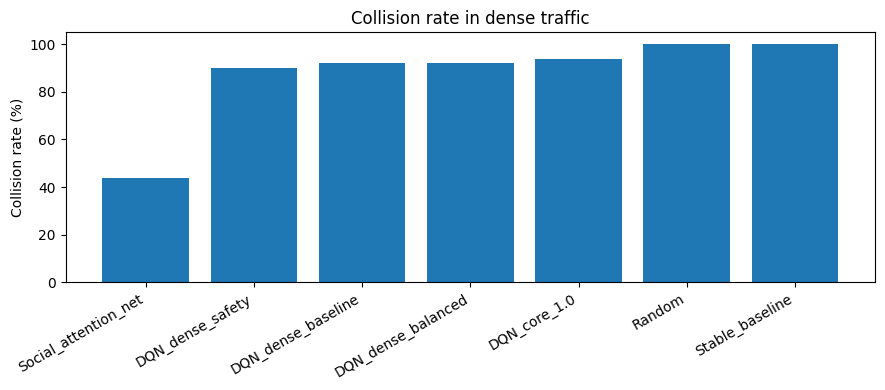

In [30]:
df_plot = load_results_table().sort_values(by="collision_rate", ascending=True)

plt.figure(figsize=(9, 4))
plt.bar(df_plot["model"], df_plot["collision_rate"])
plt.ylabel("Collision rate (%)")
plt.title("Collision rate in dense traffic")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

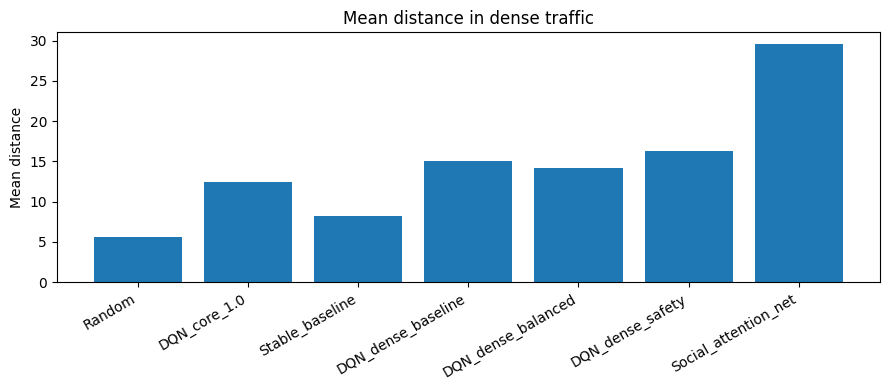

In [31]:
df_plot = load_results_table()

plt.figure(figsize=(9, 4))
plt.bar(df_plot["model"], df_plot["mean_distance"])
plt.ylabel("Mean distance")
plt.title("Mean distance in dense traffic")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

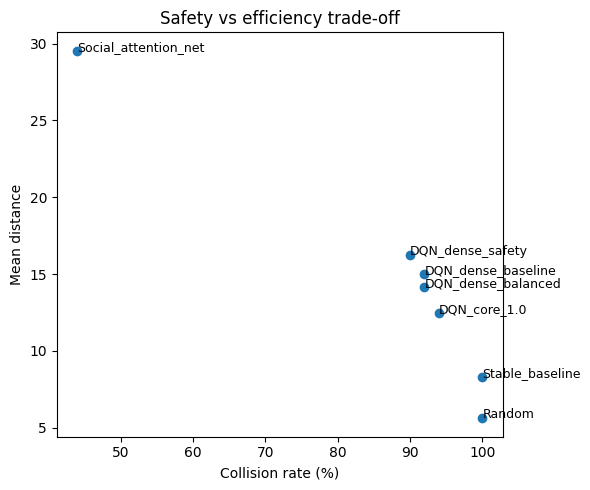

In [32]:
df_plot = load_results_table()

plt.figure(figsize=(6, 5))
plt.scatter(df_plot["collision_rate"], df_plot["mean_distance"])

for _, row in df_plot.iterrows():
    plt.text(row["collision_rate"], row["mean_distance"], row["model"], fontsize=9)

plt.xlabel("Collision rate (%)")
plt.ylabel("Mean distance")
plt.title("Safety vs efficiency trade-off")
plt.tight_layout()
plt.show()

## Full metric plots

Pour avoir une vue plus complète que le notebook initial, on trace aussi la reward moyenne et la longueur moyenne d'épisode.

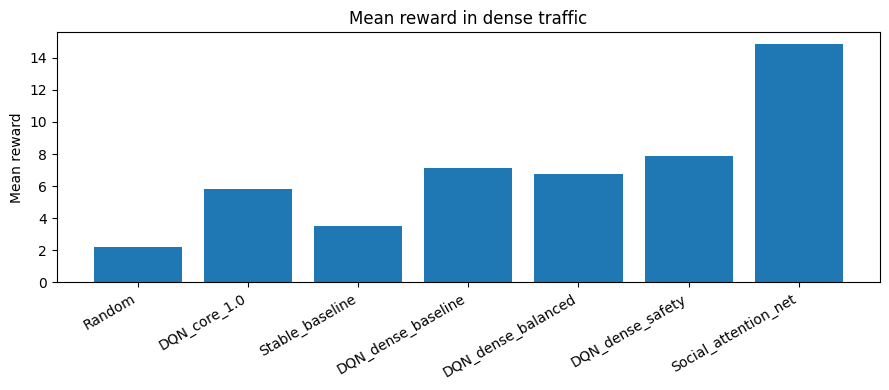

In [33]:
df_plot = load_results_table()

plt.figure(figsize=(9, 4))
plt.bar(df_plot["model"], df_plot["mean_reward"])
plt.ylabel("Mean reward")
plt.title("Mean reward in dense traffic")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

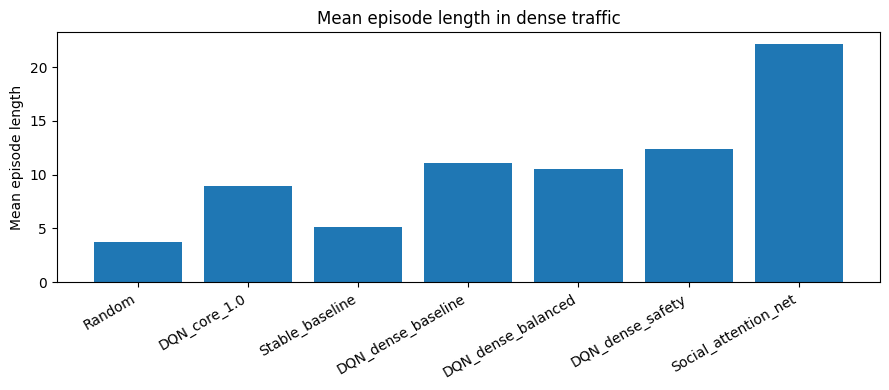

In [34]:
df_plot = load_results_table()

plt.figure(figsize=(9, 4))
plt.bar(df_plot["model"], df_plot["mean_episode_length"])
plt.ylabel("Mean episode length")
plt.title("Mean episode length in dense traffic")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Action distribution comparison

Les distributions d'action sont stockées dans le CSV via `action_count_*` et `action_pct_*`.

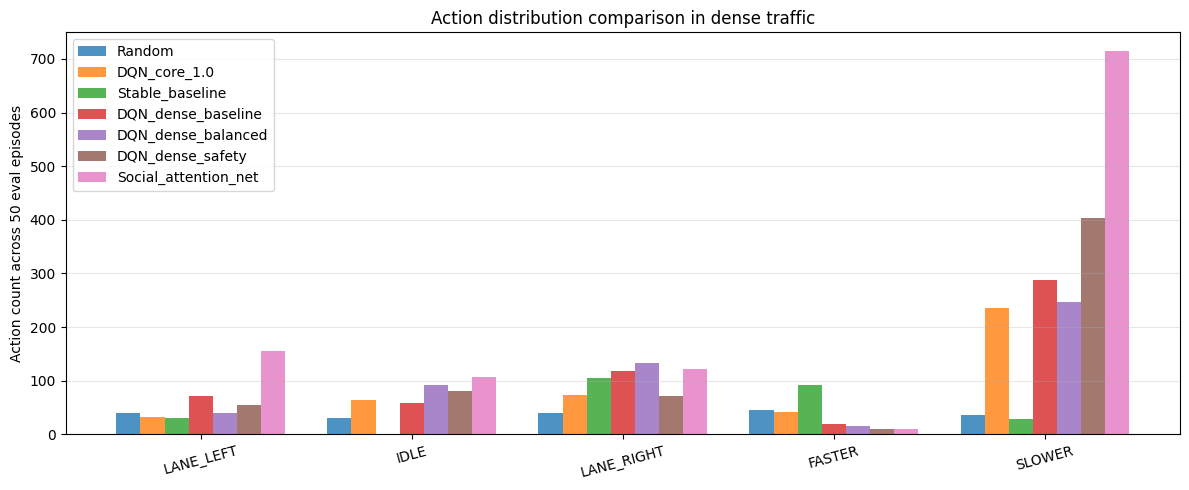

In [35]:
df_plot = load_results_table()

x = np.arange(N_ACTIONS)
width = 0.8 / max(len(df_plot), 1)

plt.figure(figsize=(12, 5))
for i, (_, row) in enumerate(df_plot.iterrows()):
    counts = [row[f"action_count_{a}"] for a in range(N_ACTIONS)]
    plt.bar(
        x + i * width - (len(df_plot) - 1) * width / 2,
        counts,
        width=width,
        label=row["model"],
        alpha=0.8,
    )

plt.xticks(x, [ACTION_LABELS[a] for a in range(N_ACTIONS)], rotation=15)
plt.ylabel("Action count across 50 eval episodes")
plt.title("Action distribution comparison in dense traffic")
plt.legend()
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## Optional qualitative comparison on one seed

In [36]:
def compare_agents(get_actions, agent_names, config, seed, n_actions, action_labels=None):
    episodes_data = []

    for get_action in get_actions:
        env = make_env(config)
        state, _ = env.reset(seed=seed)

        rewards = []
        actions = []
        speeds = []

        done = False
        while not done:
            action = get_action(state)
            actions.append(action)
            state, reward, terminated, truncated, _ = env.step(action)

            rewards.append(reward)
            speeds.append(env.unwrapped.vehicle.speed)
            done = terminated or truncated

        env.close()

        episodes_data.append({
            "rewards": np.array(rewards),
            "actions": np.array(actions),
            "speeds": np.array(speeds),
        })

    n_agents = len(episodes_data)
    colors = plt.cm.tab10.colors

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    ax = axes[0]
    for i, data in enumerate(episodes_data):
        ax.plot(np.cumsum(data["rewards"]), lw=2, color=colors[i], label=agent_names[i])
    ax.set_xlabel("Step")
    ax.set_ylabel("Cumulative Reward")
    ax.set_title("Cumulative reward")
    ax.legend()
    ax.grid(alpha=0.3)

    ax = axes[1]
    for i, data in enumerate(episodes_data):
        ax.plot(data["speeds"], lw=2, color=colors[i], label=agent_names[i])
    ax.set_xlabel("Step")
    ax.set_ylabel("Speed")
    ax.set_title("Speed over time")
    ax.legend()
    ax.grid(alpha=0.3)

    ax = axes[2]
    x = np.arange(n_actions)
    width = 0.8 / n_agents

    labels = [action_labels.get(i, str(i)) for i in range(n_actions)] if action_labels is not None else [str(i) for i in range(n_actions)]

    for i, data in enumerate(episodes_data):
        counts = np.bincount(data["actions"], minlength=n_actions)
        ax.bar(x + i * width - (n_agents - 1) * width / 2, counts, width, label=agent_names[i], alpha=0.8, color=colors[i])

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15)
    ax.set_ylabel("Count")
    ax.set_title("Action distribution")
    ax.legend()
    ax.grid(alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()


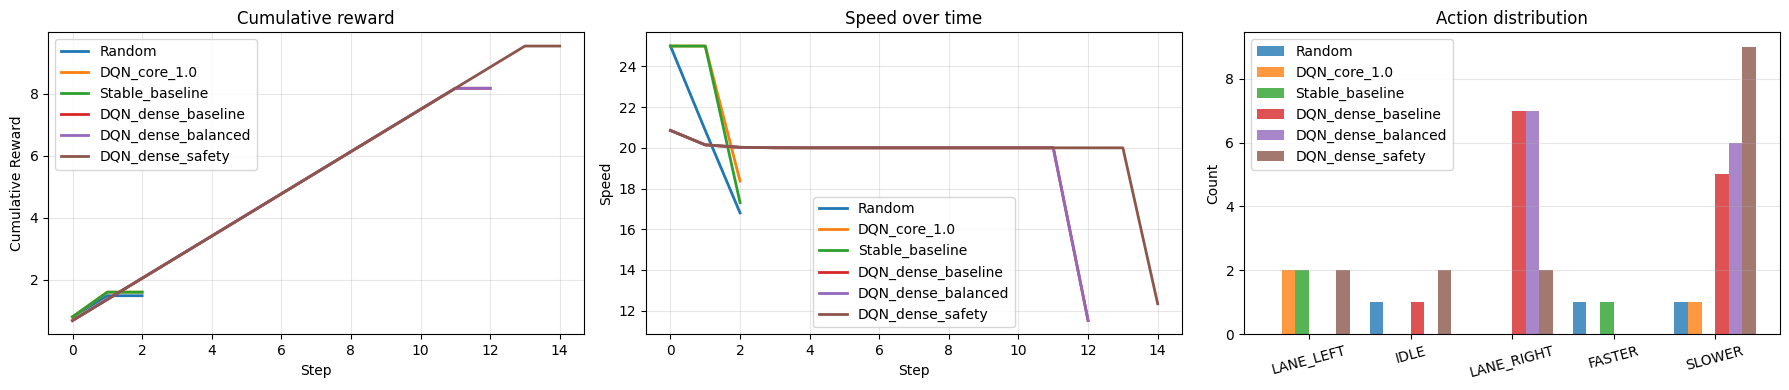

In [37]:
SEED_FOR_VIS = 50

policies_for_vis = [
    make_random_policy(),
    make_custom_policy(CORE_DQN_CHECKPOINT),
    make_sb_policy(STABLE_BASELINE_PATH),
    make_custom_policy(DENSE_BASELINE_CHECKPOINT),
    make_custom_policy(DENSE_BALANCED_CHECKPOINT),
    make_custom_policy(DENSE_SAFETY_CHECKPOINT),
]

names_for_vis = [
    "Random",
    "DQN_core_1.0",
    "Stable_baseline",
    "DQN_dense_baseline",
    "DQN_dense_balanced",
    "DQN_dense_safety",
]

compare_agents(
    get_actions=policies_for_vis,
    agent_names=names_for_vis,
    config=EVAL_CONFIG,
    seed=SEED_FOR_VIS,
    n_actions=N_ACTIONS,
    action_labels=ACTION_LABELS,
)